<a href="https://colab.research.google.com/github/PanconquesoHH/Laboratorios-ia/blob/main/LAB5_PYTORCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación multiclase One-vs-All con PyTorch y ResNet18

Este cuadernillo conserva la estructura de `ejemplo.ipynb`: normalización, regresión logística binaria, `OneVsAll`, matriz `all_theta` y `predictOneVsAll`. La diferencia es que ResNet18 preentrenada reemplaza HOG como extractor de características. **ResNet18 no realiza la clasificación final**; el clasificador continúa siendo regresión logística One-vs-All implementada con PyTorch.


In [14]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Utilizado para la manipulación de directorios y rutas
import os, gc, random, time, warnings

# Cálculo científico y vectorial para Python
import numpy as np
import pandas as pd

# Librería para gráficos
from matplotlib import pyplot

# Características visuales
from skimage.feature import hog

# División y métricas
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# PyTorch
import torch
from torch import nn
from torch.utils.data import Dataset, TensorDataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights

%matplotlib inline
warnings.filterwarnings('ignore')
SEMILLA = 42
random.seed(SEMILLA); np.random.seed(SEMILLA); torch.manual_seed(SEMILLA)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device)


Dispositivo: cuda


## 1. Carga de los datos

Como el CSV es grande, primero se revisan 300 filas para detectar si la etiqueta está al principio o al final. Después se carga como `uint8` para reducir el uso de RAM.


In [16]:
# Número de clases que se utilizarán. Puede cambiarse, por ejemplo, a 5, 10 o 15.
num_labels = 5
RUTA_CSV = '/content/drive/MyDrive/Lab 5/train.csv'

muestra = pd.read_csv(RUTA_CSV, header=None, nrows=300, dtype=str)

def puntuacion_etiqueta(serie):
    s = pd.to_numeric(serie, errors='coerce').dropna()
    if len(s) == 0: return -1e9
    unicos = s.nunique()
    enteros = np.allclose(s, np.round(s))
    return (5 if enteros else 0) + (5 if 2 <= unicos <= 200 else -5) - abs(unicos-101)/101

candidatos = [muestra.columns[0], muestra.columns[-1]]
label_col = max(candidatos, key=lambda c: puntuacion_etiqueta(muestra[c]))
primera = pd.to_numeric(muestra.iloc[0, [0, -1]], errors='coerce')
filas_a_omitir = 1 if primera.isna().any() else 0
del muestra; gc.collect()

data = pd.read_csv(RUTA_CSV, header=None, skiprows=filas_a_omitir,
                   dtype=np.uint8, low_memory=False)
datos = data.to_numpy(dtype=np.uint8, copy=False)
pos_label = data.columns.get_loc(label_col)

if pos_label == 0:
    y_total = datos[:, 0].astype(np.int16)
    X_total = datos[:, 1:]
else:
    y_total = datos[:, -1].astype(np.int16)
    X_total = datos[:, :-1]

del data; gc.collect()
lado = int(np.sqrt(X_total.shape[1]))
assert lado * lado == X_total.shape[1]
print('Dataset completo:', X_total.shape)
print('Etiqueta detectada en la columna:', label_col)
print('Imagen:', lado, 'x', lado)


Dataset completo: (75750, 4096)
Etiqueta detectada en la columna: 4096
Imagen: 64 x 64


### 1.1 Subconjunto multiclase

Se toman las primeras 10 etiquetas ordenadas. Esta selección es fija y no consulta la precisión, por lo que no elige artificialmente las clases más fáciles.


In [17]:
clases_disponibles = np.sort(np.unique(y_total))
CLASES_ELEGIDAS = clases_disponibles[:num_labels]
mask = np.isin(y_total, CLASES_ELEGIDAS)
indices_sub = np.where(mask)[0]

# Las etiquetas se convierten a 0, 1, ..., num_labels-1.
clase_a_indice = {clase: i for i, clase in enumerate(CLASES_ELEGIDAS)}
indice_a_clase = {i: clase for clase, i in clase_a_indice.items()}
y = np.array([clase_a_indice[v] for v in y_total[indices_sub]], dtype=np.int64)

idx_train, idx_test = train_test_split(
    np.arange(len(indices_sub)), test_size=0.20, random_state=SEMILLA, stratify=y)
print('Clases originales:', CLASES_ELEGIDAS)
print('Entrenamiento:', len(idx_train), '| Prueba:', len(idx_test))


Clases originales: [0 1 2 3 4]
Entrenamiento: 3000 | Prueba: 750


### 1.2 Visualización de los datos


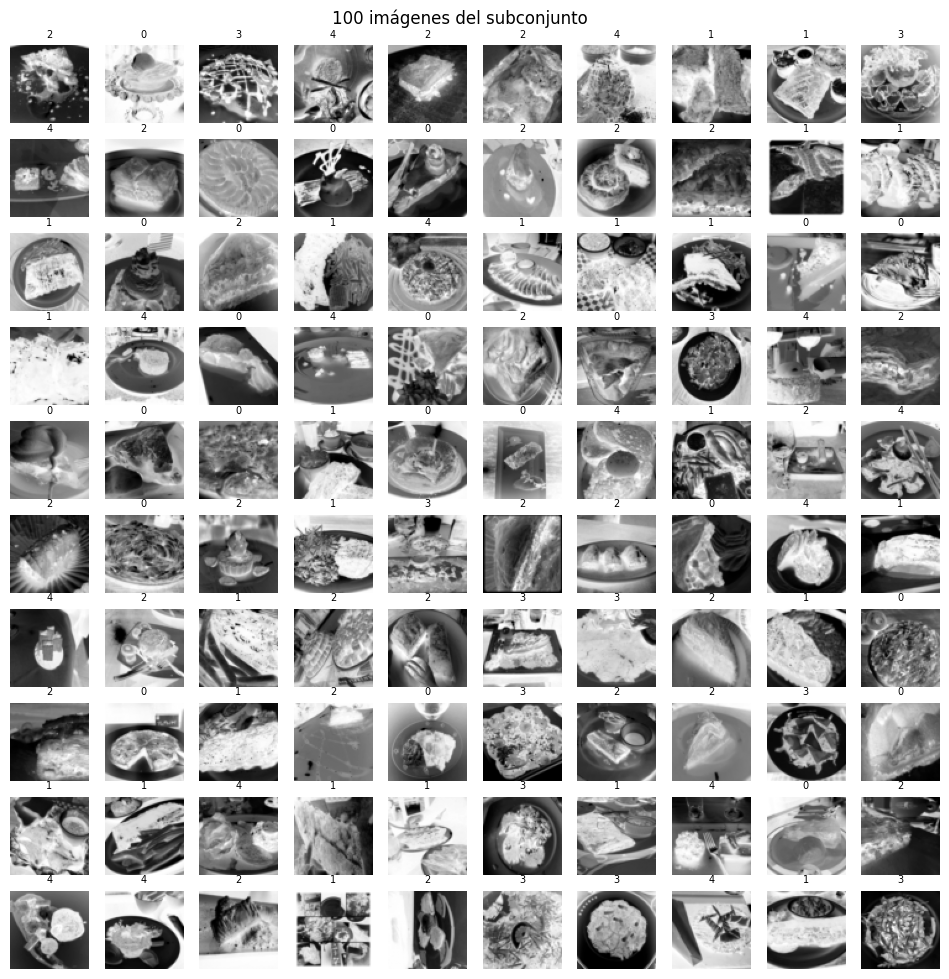

In [18]:
def displayData(X, example_width, titulos=None, figsize=(12, 12)):
    filas = int(np.floor(np.sqrt(len(X))))
    columnas = int(np.ceil(len(X) / filas))
    fig, axes = pyplot.subplots(filas, columnas, figsize=figsize)
    for i, ax in enumerate(np.atleast_1d(axes).ravel()):
        if i < len(X):
            ax.imshow(X[i].reshape(example_width, example_width), cmap='gray')
            if titulos is not None: ax.set_title(str(titulos[i]), fontsize=7)
        ax.axis('off')
    return fig

pos_visual = np.random.choice(len(indices_sub), min(100, len(indices_sub)), replace=False)
filas_visual = indices_sub[pos_visual]
displayData(X_total[filas_visual], lado, y_total[filas_visual])
pyplot.suptitle('100 imágenes del subconjunto', y=.91)
pyplot.show()


### 1.3 Extracción de características con ResNet18

Las características HOG no describían suficientemente las texturas y formas complejas de los alimentos. Aquí se utiliza una ResNet18 entrenada previamente con ImageNet. Cada imagen gris se convierte a tres canales, se redimensiona a 224×224 y se normaliza. Se elimina la última capa de ResNet para obtener un vector de **512 características** por imagen.

La primera ejecución descargará aproximadamente 45 MB de pesos. Es recomendable activar GPU en Colab.


In [19]:
# Pesos preentrenados y modelo extractor
pesos = ResNet18_Weights.DEFAULT
modelo_caracteristicas = resnet18(weights=pesos)
modelo_caracteristicas.fc = nn.Identity()
modelo_caracteristicas = modelo_caracteristicas.to(device)
modelo_caracteristicas.eval()

media_imagenet = torch.tensor([0.485, 0.456, 0.406]).reshape(3, 1, 1)
desviacion_imagenet = torch.tensor([0.229, 0.224, 0.225]).reshape(3, 1, 1)

class DatasetCaracteristicas(Dataset):
    def __init__(self, X_total, filas, lado):
        self.X_total = X_total
        self.filas = np.asarray(filas, dtype=np.int32)
        self.lado = lado

    def __len__(self):
        return len(self.filas)

    def __getitem__(self, ix):
        fila = self.filas[ix]
        imagen = self.X_total[fila].reshape(1, self.lado, self.lado)
        imagen = torch.from_numpy(imagen.copy()).float() / 255.0
        imagen = imagen.repeat(3, 1, 1)
        imagen = torch.nn.functional.interpolate(
            imagen.unsqueeze(0), size=(224, 224), mode='bilinear',
            align_corners=False).squeeze(0)
        imagen = (imagen - media_imagenet) / desviacion_imagenet
        return imagen

dataset_caracteristicas = DatasetCaracteristicas(X_total, indices_sub, lado)
dataloader_caracteristicas = DataLoader(
    dataset_caracteristicas, batch_size=64, shuffle=False,
    num_workers=0, pin_memory=torch.cuda.is_available())

lista_caracteristicas = []
inicio = time.time()
modelo_caracteristicas.eval()
with torch.no_grad():
    for numero_batch, imagenes in enumerate(dataloader_caracteristicas, start=1):
        imagenes = imagenes.to(device, non_blocking=True)
        caracteristicas = modelo_caracteristicas(imagenes)
        lista_caracteristicas.append(caracteristicas.cpu().numpy())
        if numero_batch % 20 == 0:
            procesadas = min(numero_batch * 64, len(dataset_caracteristicas))
            print(f'Imágenes procesadas: {procesadas}/{len(dataset_caracteristicas)}')

X = np.concatenate(lista_caracteristicas, axis=0).astype(np.float32)
del lista_caracteristicas
if torch.cuda.is_available(): torch.cuda.empty_cache()
gc.collect()

print('Forma de X:', X.shape)
print('Forma de y:', y.shape)
print('Número de características:', X.shape[1])
print('Tiempo de extracción: %.1f minutos' % ((time.time()-inicio)/60))
print(X[0, :20])
print(y[:20])


Imágenes procesadas: 1280/3750
Imágenes procesadas: 2560/3750
Forma de X: (3750, 512)
Forma de y: (3750,)
Número de características: 512
Tiempo de extracción: 0.2 minutos
[1.3968546e-04 6.1292209e-02 7.9737585e-03 1.6401476e+00 4.8334312e-01
 4.8372182e-01 9.4154662e-01 7.9330736e-01 9.8298061e-01 3.5376725e-01
 0.0000000e+00 6.6065496e-01 1.5769073e-01 1.0099906e+00 3.5558450e-01
 7.8152120e-01 6.0635793e-01 9.9536933e-02 3.3213884e-02 1.4747109e-01]
[2 3 1 2 2 3 4 2 1 2 1 0 4 4 1 1 0 3 3 3]


### 1.4 Normalización de características


In [20]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Mu y sigma se calculan solo con entrenamiento para evitar fuga de información.
X_train_sin_norm = X[idx_train]
X_test_sin_norm = X[idx_test]
X_train, mu, sigma = featureNormalize(X_train_sin_norm)
X_test = (X_test_sin_norm - mu) / sigma
y_train, y_test = y[idx_train], y[idx_test]
print(X_train[0, :20])
print(y_train[:20])


[ 1.3672318   1.0317279  -0.12827684 -0.8112905   1.2011418  -0.9606596
 -0.5336267   0.51238483 -0.45179188  0.36112383  0.51613146  0.70406103
  0.588465   -0.2919962   0.29067925  1.8962888  -1.0861126   0.5552818
 -0.39704028 -1.1094372 ]
[0 4 2 4 1 0 1 4 3 0 3 4 2 1 0 1 2 4 0 1]


## 2. Vectorización de regresión logística

Para cada clase se entrena un clasificador binario. La salida lineal es $z=X	heta$ y la sigmoide la convierte en una probabilidad:

$$g(z)=rac{1}{1+e^{-z}}$$

PyTorch calcula automáticamente el gradiente mediante `loss.backward()`.


In [21]:
def sigmoid(z):
    return torch.sigmoid(z)

def calcularCosto(logits, y_actual, criterion):
    return criterion(logits, y_actual)


### 2.1 Clasificación One-vs-All

`OneVsAll` repite el entrenamiento para cada categoría. Cada modelo responde: “¿pertenece a mi clase o pertenece a las demás?”. Los parámetros aprendidos se almacenan en `all_theta`.


In [22]:
def OneVsAll(X, y, num_labels, lambda_):
    alpha = 0.001
    epochs = 300
    log_each = 50
    batch_size = 256

    X_t = torch.from_numpy(X.astype(np.float32))
    y_t = torch.from_numpy(y.astype(np.int64))
    dataset = TensorDataset(X_t, y_t)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1), dtype=np.float32)
    historiales = []

    for c in np.arange(num_labels):
        model = nn.Linear(n, 1).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([num_labels-1.], device=device))
        optimizer = torch.optim.Adam(model.parameters(), lr=alpha, weight_decay=lambda_)
        l = []

        for e in range(1, epochs + 1):
            model.train()
            _l = []
            for x_b, y_b in dataloader:
                x_b, y_b = x_b.to(device), y_b.to(device)
                y_actual = (y_b == c).float().reshape(-1, 1)
                y_pred = model(x_b)
                loss = calcularCosto(y_pred, y_actual, criterion)
                _l.append(loss.item())
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            l.append(np.mean(_l))
            if not e % log_each:
                print(f'Clase {c} - Epoch {e}/{epochs} Loss {l[-1]:.5f}')

        with torch.no_grad():
            all_theta[c, 0] = model.bias.detach().cpu().numpy()[0]
            all_theta[c, 1:] = model.weight.detach().cpu().numpy()[0]
        historiales.append(l)

    for c, l in enumerate(historiales):
        pyplot.plot(np.arange(1, len(l)+1), l, label=f'Clase {c}')
    pyplot.xlabel('Número de epochs'); pyplot.ylabel('Costo J')
    pyplot.title('Convergencia One-vs-All'); pyplot.legend(ncol=2, fontsize=7)
    pyplot.show()
    return all_theta


Clase 0 - Epoch 50/300 Loss 0.63702
Clase 0 - Epoch 100/300 Loss 0.58148
Clase 0 - Epoch 150/300 Loss 0.55510
Clase 0 - Epoch 200/300 Loss 0.53967
Clase 0 - Epoch 250/300 Loss 0.53065
Clase 0 - Epoch 300/300 Loss 0.52509
Clase 1 - Epoch 50/300 Loss 0.49551
Clase 1 - Epoch 100/300 Loss 0.42768
Clase 1 - Epoch 150/300 Loss 0.38766
Clase 1 - Epoch 200/300 Loss 0.36526
Clase 1 - Epoch 250/300 Loss 0.35179
Clase 1 - Epoch 300/300 Loss 0.34420
Clase 2 - Epoch 50/300 Loss 0.53783
Clase 2 - Epoch 100/300 Loss 0.47993
Clase 2 - Epoch 150/300 Loss 0.44968
Clase 2 - Epoch 200/300 Loss 0.43390
Clase 2 - Epoch 250/300 Loss 0.42277
Clase 2 - Epoch 300/300 Loss 0.41289
Clase 3 - Epoch 50/300 Loss 0.54523
Clase 3 - Epoch 100/300 Loss 0.48356
Clase 3 - Epoch 150/300 Loss 0.44996
Clase 3 - Epoch 200/300 Loss 0.43306
Clase 3 - Epoch 250/300 Loss 0.41720
Clase 3 - Epoch 300/300 Loss 0.40726
Clase 4 - Epoch 50/300 Loss 0.62530
Clase 4 - Epoch 100/300 Loss 0.56773
Clase 4 - Epoch 150/300 Loss 0.54508
Clase 

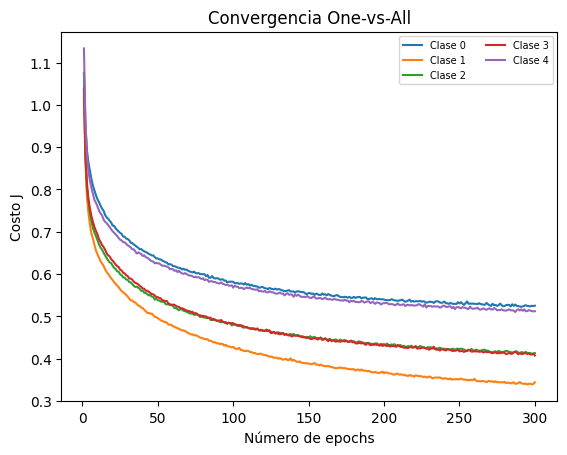

Forma de all_theta: (5, 513)
[[-1.3755269  -0.0683797   0.043853   ...  0.2118963   0.04155722
   0.04869655]
 [-2.0310867  -0.3050105   0.06781289 ... -0.31610677 -0.06503823
   0.10763924]
 [-1.677783   -0.01560958  0.07042622 ...  0.35511026  0.13948147
  -0.03782426]
 [-1.7320459  -0.22073893 -0.03935313 ... -0.16091736 -0.2875531
  -0.05605972]
 [-1.3762094   0.11797134 -0.18033287 ... -0.21590663  0.21022384
   0.10597809]]


In [23]:
lambda_ = 0.001
all_theta = OneVsAll(X_train, y_train, num_labels, lambda_)
print('Forma de all_theta:', all_theta.shape)
print(all_theta)


### 2.2 Predicción One-vs-All

Se calcula la probabilidad de cada clase y se elige la posición con el valor más alto mediante `argmax`, igual que en el cuadernillo de referencia.


In [24]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    X_bias = np.concatenate([np.ones((m, 1), dtype=np.float32),
                             X.astype(np.float32)], axis=1)
    X_t = torch.from_numpy(X_bias).to(device)
    theta_t = torch.from_numpy(all_theta).to(device)
    with torch.no_grad():
        probabilidades = sigmoid(X_t.mm(theta_t.T))
        p = torch.argmax(probabilidades, dim=1)
    return p.cpu().numpy()


## 3. Resultados

La precisión se calcula tanto en entrenamiento como en el 20% de prueba independiente.


Precisión del conjunto de entrenamiento: 79.43%
Precisión del conjunto de prueba: 60.27%


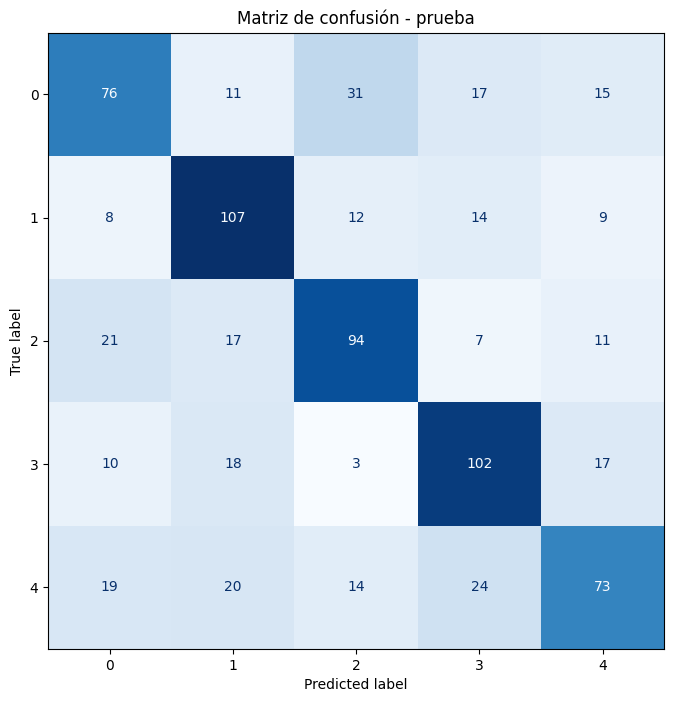

In [25]:
pred_train = predictOneVsAll(all_theta, X_train)
pred_test = predictOneVsAll(all_theta, X_test)

print('Precisión del conjunto de entrenamiento: {:.2f}%'.format(
    np.mean(pred_train == y_train) * 100))
print('Precisión del conjunto de prueba: {:.2f}%'.format(
    np.mean(pred_test == y_test) * 100))

fig, ax = pyplot.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test,
    labels=np.arange(num_labels), cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Matriz de confusión - prueba')
pyplot.show()


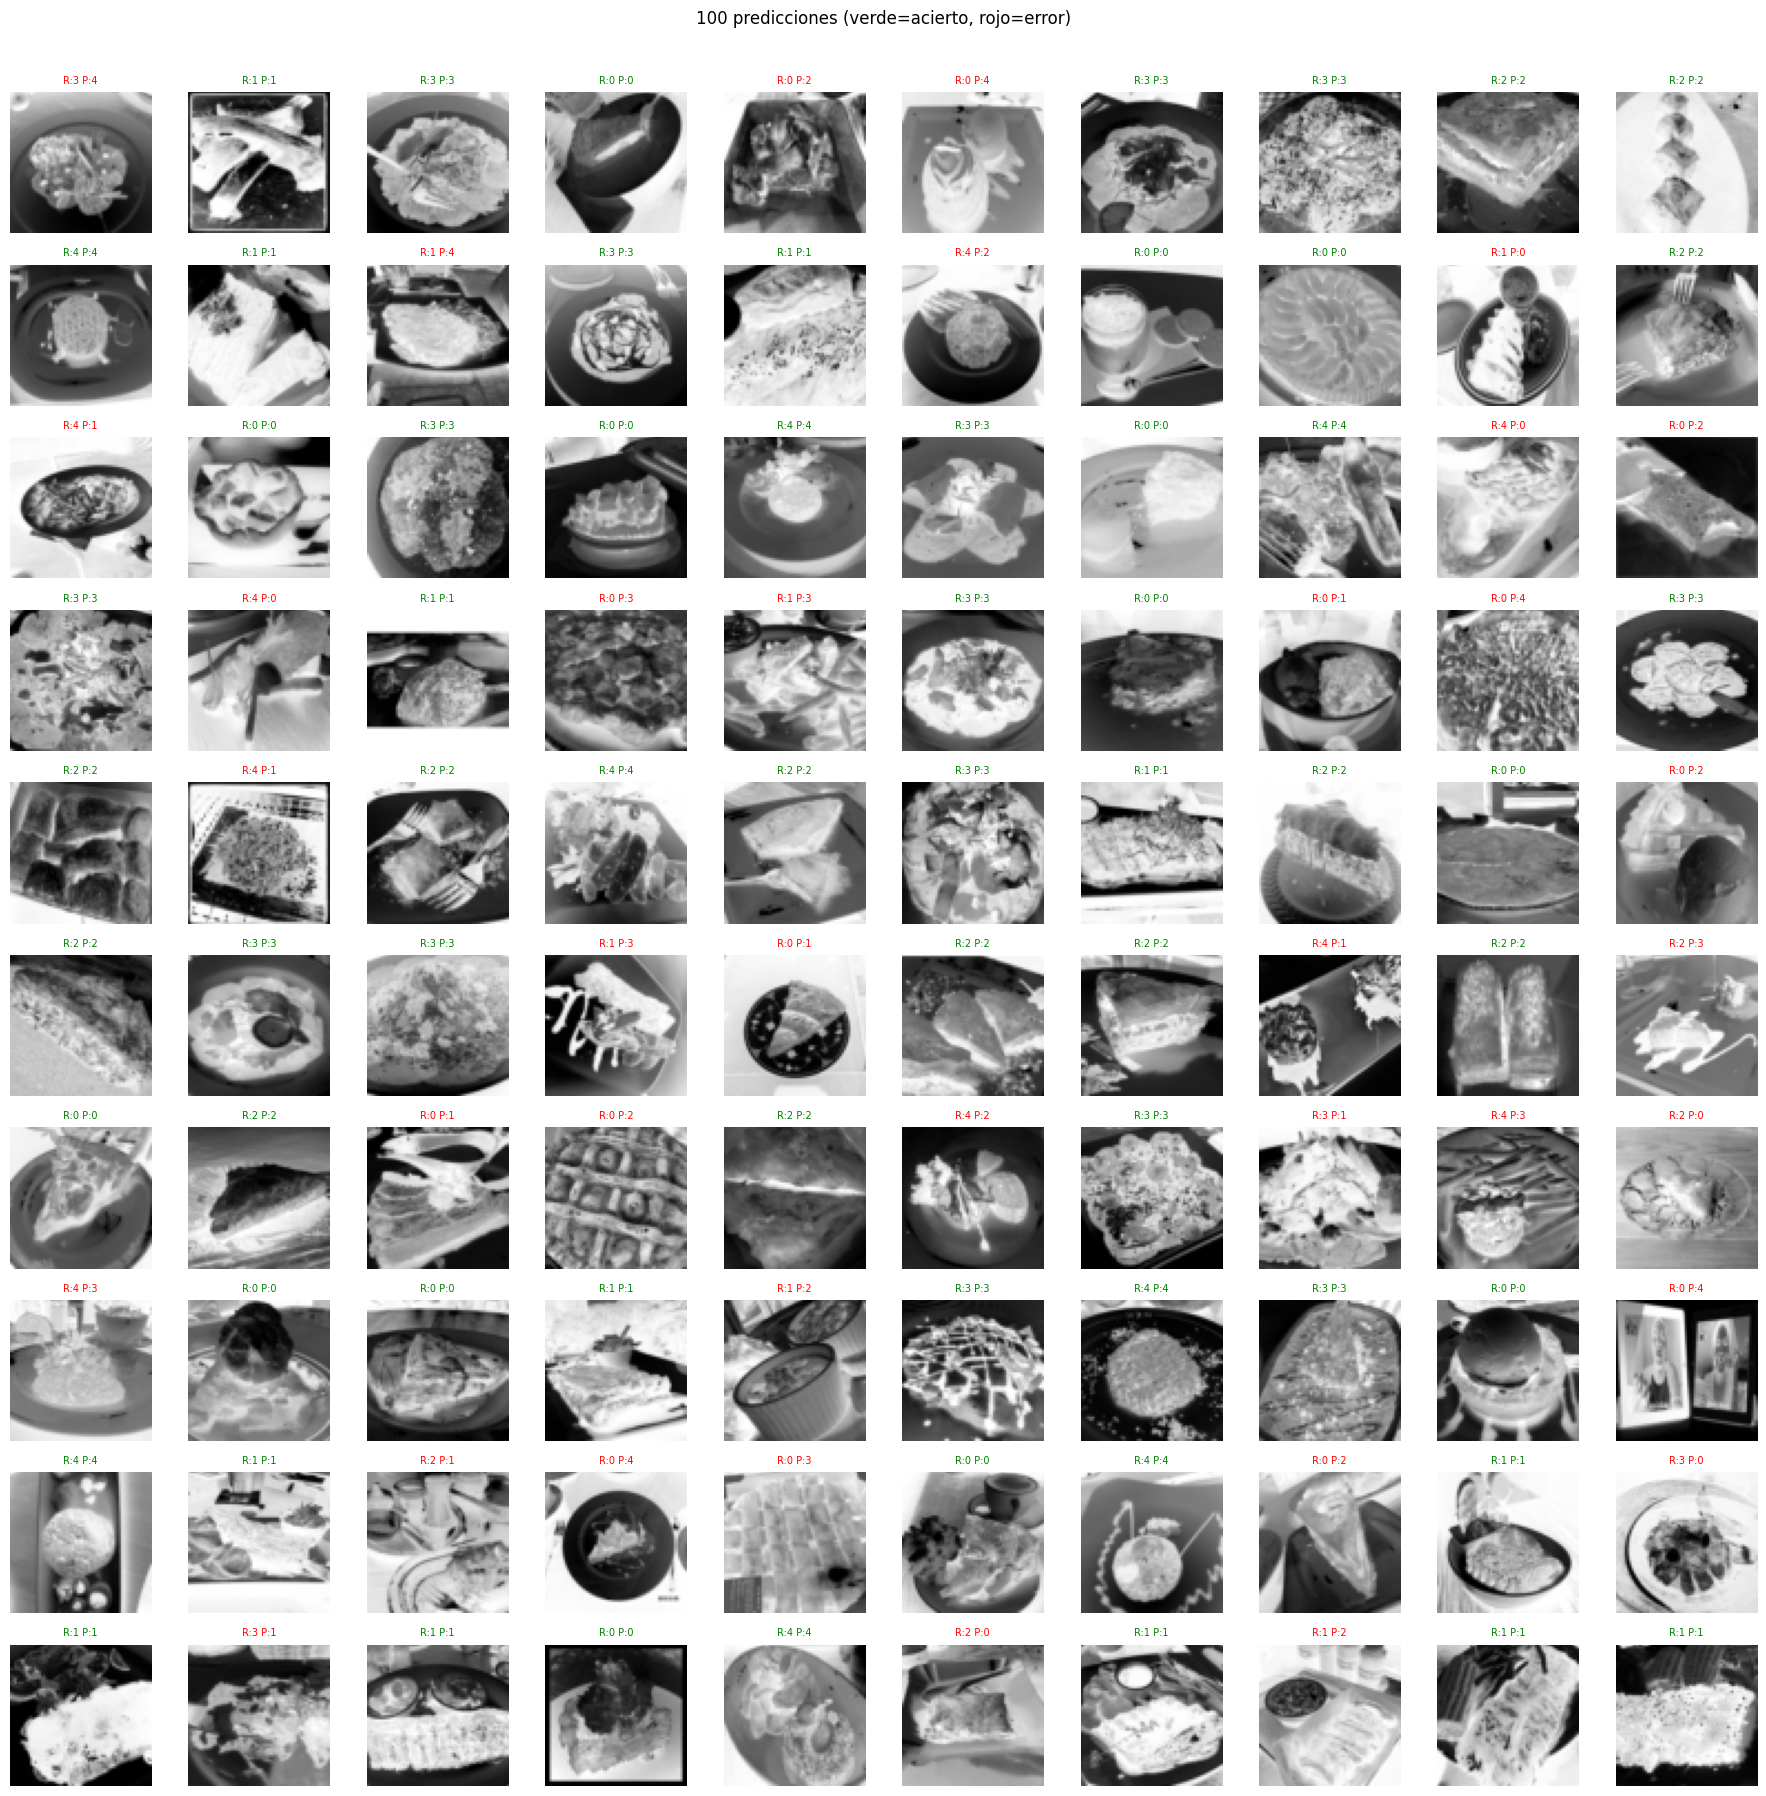

In [26]:
# Se muestran 100 predicciones de prueba.
posiciones = np.random.choice(len(idx_test), min(100, len(idx_test)), replace=False)
fig, axes = pyplot.subplots(10, 10, figsize=(18, 18))
for ax, pos in zip(axes.ravel(), posiciones):
    fila_total = indices_sub[idx_test[pos]]
    real = indice_a_clase[y_test[pos]]
    pred = indice_a_clase[pred_test[pos]]
    ax.imshow(X_total[fila_total].reshape(lado, lado), cmap='gray')
    ax.set_title(f'R:{real} P:{pred}', fontsize=7,
                 color='green' if real == pred else 'red')
    ax.axis('off')
for ax in axes.ravel()[len(posiciones):]: ax.axis('off')
pyplot.suptitle('100 predicciones (verde=acierto, rojo=error)', y=.995)
pyplot.tight_layout(rect=[0, 0, 1, .985]); pyplot.show()


## 4. Conclusión

El procedimiento conserva la lógica del cuadernillo de referencia: `featureNormalize`, clasificadores binarios, entrenamiento `OneVsAll`, matriz `all_theta`, sigmoide y predicción mediante `argmax`. PyTorch calcula los gradientes y optimiza cada regresión logística.

ResNet18 se utiliza solamente para transformar cada imagen en 512 características profundas. Esta representación suele generalizar mejor que HOG en fotografías de alimentos. El conjunto de prueba continúa separado y no se usa para entrenar, normalizar ni escoger clases. No se impone una precisión mínima: se comunica el resultado real.
